# Self-Correcting Doc Assistant
### A Teaching App: LlamaIndex · LangChain · LangGraph

This notebook builds a **corrective-RAG** question-answering system over a small local document set.
The teaching goal is to show three libraries each doing the job they are *best* at:

```
┌──────────────────┐    ┌──────────────────┐    ┌──────────────────┐
│   LlamaIndex     │    │   LangChain      │    │   LangGraph      │
│   DATA Layer     │───▶│   GENERATION     │───▶│   CONTROL Layer  │
│                  │    │   Layer          │    │                  │
│  Load · Chunk    │    │  Prompt · LLM    │    │  Grade · Retry   │
│  Embed · Index   │    │  Structured Out  │    │  Loop · Fallback │
│  Retrieve        │    │                  │    │                  │
└──────────────────┘    └──────────────────┘    └──────────────────┘
```

**Key insight:** These libraries are not competitors — each owns a different layer.
The app grades its own retrieved context, retries with a rewritten query when context is weak,
and honestly admits defeat instead of hallucinating when nothing useful is found.

## Setup

**Everything runs locally — no API keys, no fees.**

1. **Install Ollama** (the free local LLM runtime):
   - Linux/macOS: `curl -fsSL https://ollama.ai/install.sh | sh`
   - Windows: download the installer from [ollama.com](https://ollama.com)
   - Verify it is running: `ollama list`

2. **Pull the LLM** (one-time download, ~2 GB):
   ```
   ollama pull llama3.2:3b
   ```
   > `llama3.2:3b` is fast and small — good for demos.
   > For higher-quality answers try `llama3.1:8b` (~5 GB) and update `LLM_MODEL` in Cell 04.

3. **Run Cell 03** (pip install) — only needed once, then **restart the kernel**.

> **Cost: $0.00.**
> Ollama runs the LLM on your own hardware; `BAAI/bge-small-en-v1.5` handles embeddings
> locally too. No internet needed after the initial downloads.

In [1]:
# ── Install all dependencies. Run once, then RESTART the kernel. ─────────────
import subprocess, sys                       # stdlib: run shell commands; sys.executable = this Python

PACKAGES = [
    "llama-index-core",                      # LlamaIndex core — load, chunk, embed, index, retrieve
    "llama-index-vector-stores-chroma",      # LlamaIndex adapter: use Chroma as the vector store
    "llama-index-embeddings-huggingface",    # LlamaIndex adapter: run HuggingFace models locally
    "langchain",                             # LangChain — compose prompts, LLM calls, output parsers
    "langchain-core",                        # shared abstractions required by all LangChain packages
    "langchain-ollama",                      # LangChain adapter: connects chains to a local Ollama server
    "langgraph",                             # LangGraph — state-machine graphs for agentic control flow
    "chromadb",                              # Chroma — fast local vector database with on-disk persistence
    "gradio",                                # Gradio — builds the interactive UI in the final cell
]

subprocess.check_call(                       # run pip; raises CalledProcessError if any package fails
    [sys.executable,                         # use the exact Python interpreter running this notebook
     "-m", "pip", "install",                # invoke pip's install sub-command
     *PACKAGES,                              # unpack the list into individual positional arguments
     "-q"]                                   # quiet: suppress verbose installer output
)
print("✅ Installation complete — restart the kernel, then continue.")

✅ Installation complete — restart the kernel, then continue.


In [2]:
# ─────────────────────────────────────────────────────────────
#  IMPORTS & CONFIGURATION
#  All constants live here — one place to change everything.
# ─────────────────────────────────────────────────────────────
import os                                    # stdlib: interact with the operating system
import textwrap                              # stdlib: reflow long strings to a max line width
from pathlib import Path                     # Path objects for OS-independent file-system operations
from operator import add                     # built-in add(a,b) — used as a LangGraph list reducer
from typing import TypedDict, Annotated, List, Optional, Literal  # type hints used throughout

DATA_DIR    = Path("data")                   # folder that holds our handbook markdown files
STORAGE_DIR = Path("/tmp/chroma_handbook")  # /tmp avoids special chars (parentheses, commas) in notebook path that break Chroma's Rust backend
DATA_DIR.mkdir(exist_ok=True)               # create data/ now; harmless if it already exists
STORAGE_DIR.mkdir(parents=True, exist_ok=True)  # parents=True needed since /tmp/chroma_handbook may not exist yet

# ── LLM (Ollama — local, free, no API key) ─────────────────────────────────
LLM_MODEL    = "phi3:latest"                # Ollama model used for generation and query rewriting
GRADER_MODEL = "phi3:latest"               # Ollama model used for relevance grading (same = fine, no cost diff)

# ── Embeddings (local HuggingFace — also free) ────────────────────────────
EMBED_MODEL_NAME  = "BAAI/bge-small-en-v1.5"  # downloads ~130 MB once, then runs fully offline
CHROMA_COLLECTION = "handbook"              # name of the Chroma collection that stores our vectors

# ── Retrieval & graph tuning ───────────────────────────────────────────────
TOP_K         = 4                           # how many chunks to return per retrieval query
MAX_RETRIES   = 2                           # max query rewrites before falling back to "I don't know"
CHUNK_SIZE    = 512                         # maximum tokens per text chunk
CHUNK_OVERLAP = 64                          # tokens shared between neighbouring chunks for context continuity

print("✅ Config loaded.")
print(f"   LLM: {LLM_MODEL} (via Ollama)  |  Embeddings: {EMBED_MODEL_NAME} (local)")

✅ Config loaded.
   LLM: phi3:latest (via Ollama)  |  Embeddings: BAAI/bge-small-en-v1.5 (local)


In [3]:
# ─────────────────────────────────────────────────────────────
#  OLLAMA CONNECTION CHECK
#  Confirms Ollama is running and the model is pulled.
#  Uses the Ollama HTTP API (fast, ~100 ms) instead of the
#  subprocess CLI so this cell never times out on slow systems.
#  Fix any issues here before proceeding to Stage 2.
# ─────────────────────────────────────────────────────────────
import urllib.request, json                 # stdlib: HTTP request and JSON parsing — no extra deps

def check_ollama(model: str = LLM_MODEL) -> bool:  # default to the configured LLM_MODEL
    try:
        with urllib.request.urlopen(        # open the Ollama REST endpoint that lists pulled models
            "http://localhost:11434/api/tags",
            timeout=10                      # 10 s is plenty; the HTTP response arrives in < 1 s
        ) as response:
            data = json.loads(response.read())   # parse the JSON body into a Python dict
    except OSError:                         # covers ConnectionRefusedError + socket timeout
        print("❌ Ollama is not responding on localhost:11434.")
        print("   Start the server with:  ollama serve")
        return False

    available = [m["name"] for m in data.get("models", [])]  # list of "name:tag" strings
    base_name = model.split(":")[0]                           # "llama3.2:3b" → "llama3.2"
    match = next(                                             # find first name whose base matches
        (n for n in available if n.split(":")[0] == base_name), None
    )

    if match:
        print(f"✅ Ollama running  |  model '{match}' is available")
        if match != model:                  # warn if the tag differs (e.g. :latest vs :3b)
            print(f"   ℹ️  Config uses '{model}' but installed tag is '{match}'.")
            print(f"      Ollama will use '{match}' automatically.")
        return True
    else:
        print(f"⚠️  Ollama is running but no '{base_name}' model is installed.")
        print(f"   Available: {available}")
        print(f"   Pull it with:  ollama pull {model}")
        return False

check_ollama()                              # run the check immediately when this cell executes

✅ Ollama running  |  model 'phi3:latest' is available


True

In [4]:
# ─────────────────────────────────────────────────────────────
#  SAMPLE DATA — Fictional Employee Handbook (5 markdown files)
#
#  Answerable:    "How many PTO days do new employees get?"
#  Unanswerable:  "What is the policy on cryptocurrency payments?"
# ─────────────────────────────────────────────────────────────

PTO_POLICY_MD = """
# PTO Policy

## Paid Time Off for Full-Time Employees

All full-time employees at Meridian Software receive **20 PTO days per calendar year**
starting from their first day of employment. New employees in their first 90 days receive
the same entitlement and may take PTO immediately with manager approval.

PTO days do not roll over into the following year. Any unused days are forfeited on
December 31. Employees who resign or are terminated are paid out for unused PTO days
accrued in the current calendar year.

### Requesting Time Off
Submit a PTO request in the HR portal at least two weeks in advance for planned absences.
For urgent or unplanned absences, notify your manager as soon as possible.
"""                                         # paid time off — contains the "20 PTO days" answer fact

REMOTE_WORK_MD = """
# Remote Work Policy

## Hybrid-First Work Environment

Meridian Software operates on a **hybrid-first** model. Employees may work remotely up to
**3 days per week**. The remaining 2 days should be worked from the office or an approved
co-working space.

Fully remote arrangements require written approval from the department head and HR,
and are reviewed annually.

### Equipment and Stipend
The company provides a laptop and standard peripherals. A monthly **home-office stipend
of $75** covers internet and ergonomic expenses. Submit receipts through Expensify within
30 days of purchase.
"""                                         # hybrid work rules and the $75/month home-office stipend

EXPENSE_POLICY_MD = """
# Expense Policy

## Reimbursable Business Expenses

Meridian Software reimburses reasonable, necessary business expenses with receipts.
Common reimbursable categories:
- Client meals and entertainment (up to **$100 per person**)
- Conference registration and travel
- Professional development books and courses (up to **$500 per year**)
- Software subscriptions pre-approved by your manager

### Submitting Expenses
Submit within **30 days** of purchase via the Expensify portal.
Expenses over **$500** require manager pre-approval before purchase.
Receipts are required for all expenses over $25.
"""                                         # expense limits and the 30-day submission rule

CODE_OF_CONDUCT_MD = """
# Code of Conduct

## Our Commitment

Meridian Software is committed to a respectful, inclusive, harassment-free workplace.
All employees, contractors, and visitors are expected to treat one another with dignity.

### Prohibited Conduct
- Harassment or discrimination based on race, gender, age, religion, disability,
  or any other protected characteristic
- Bullying, intimidation, or retaliation against anyone who raises a concern
- Sharing confidential company or client information outside authorized channels

### Reporting
Report violations to HR at hr@meridian.example or the anonymous ethics hotline:
1-800-555-ETHICS. All reports are treated confidentially.
"""                                         # conduct rules and how to report violations

ONBOARDING_MD = """
# Onboarding Guide

## Your First Two Weeks at Meridian

**Day 1:** IT setup, security training, and a tour with your onboarding buddy — a peer
assigned to help you get oriented during your first month.

**Week 1:** Meet your team, attend the Friday All Hands, and complete mandatory compliance
training (approximately 2 hours).

**Week 2:** Shadow a senior team member, complete your 30-day goals document with your
manager, and schedule your first 1-on-1.

### Key Contacts
- IT helpdesk: it@meridian.example
- HR onboarding: onboarding@meridian.example
- Your People Operations partner: listed in your offer letter
"""                                         # first-two-weeks timeline and key contact emails

docs = {                                    # maps output filename → markdown content
    "pto_policy.md":          PTO_POLICY_MD,      # PTO document
    "remote_work_policy.md":  REMOTE_WORK_MD,     # remote work document
    "expense_policy.md":      EXPENSE_POLICY_MD,  # expense document
    "code_of_conduct.md":     CODE_OF_CONDUCT_MD, # conduct document
    "onboarding.md":          ONBOARDING_MD,      # onboarding document
}

for filename, content in docs.items():      # iterate over each (filename, text) pair
    (DATA_DIR / filename).write_text(content)  # write the markdown string to disk inside data/

print(f"✅ Created {len(docs)} handbook documents in {DATA_DIR}/")
for f in sorted(DATA_DIR.iterdir()):        # list files in alphabetical order for a quick sanity-check
    print(f"   {f.name}")                   # print just the filename, not the full path

✅ Created 5 handbook documents in data/
   01_dev_environment_and_collaboration.md
   02_python_programming_for_ai_and_data_science.md
   03_relational_databases_and_sql.md
   04_descriptive_analytics_and_visualization.md
   05_regression_and_evaluation_foundations.md
   06_trees_ensembles_and_model_selection.md
   07_text_processing_and_named_entity_recognition.md
   08_embeddings_and_semantic_representations.md
   09_transformer_architectures_and_fine_tuning.md
   10_pretrained_inference_for_qa_and_summarization.md
   11_rag_systems_and_vector_retrieval.md
   12_knowledge_graphs_rdf_and_sparql.md
   13_entity_linking_kg_completion_and_gnn_literacy.md
   14_deploying_as_a_multi_service_stack.md
   15_monitoring_evaluation_and_automated_quality_benchmarks.md
   code_of_conduct.md
   expense_policy.md
   onboarding.md
   pto_policy.md
   remote_work_policy.md


---
## Stage 1 — LlamaIndex: The Data Layer

**What LlamaIndex does here:**
It handles the entire data pipeline — reading files, splitting text into overlapping chunks,
embedding those chunks into vectors, and storing them so you can search by meaning.

| Function | Job |
|----------|-----|
| `ingest()` | Load `data/`, chunk every doc, embed each chunk with a local BGE model, persist to `storage/` via Chroma |
| `load_index()` | Reload the persisted index from disk (no re-embedding) |
| `retrieve(query)` | Return the top-k most relevant chunks as plain strings |

**The habit to build:** always eyeball retrieval *before* adding an LLM.
Most bad RAG apps are actually bad retrieval apps.

In [5]:
# ─────────────────────────────────────────────────────────────
#  STAGE 1 — INGEST   (mirrors src/ingest.py)
#
#  LlamaIndex pipeline:
#    SimpleDirectoryReader  → load markdown files as Documents
#    SentenceSplitter       → split each Document into overlapping Nodes (chunks)
#    HuggingFaceEmbedding   → embed each Node text into a dense float vector
#    ChromaVectorStore      → store vectors in Chroma (in-memory)
#    VectorStoreIndex       → LlamaIndex index abstraction over the vector store
#
#  Why EphemeralClient instead of PersistentClient?
#  chromadb 1.x's Rust backend has an SQLite schema bug with PersistentClient
#  ("no such table: collections") on this Ollama version's environment.
#  EphemeralClient keeps everything in-memory for the life of the kernel —
# 
#
#  Why create the client only once?
#  chromadb 1.x's Rust backend shares SQLite state across all EphemeralClient
#  instances. Replacing the client (e.g. on re-run) causes the old instance's
#  GC to corrupt the shared schema, producing "no such table: collections".
#  Fix: keep one client per kernel session; delete + recreate the collection
#  to get a clean slate on each ingest() call.
# ─────────────────────────────────────────────────────────────

from llama_index.core import (
    VectorStoreIndex,                       # LlamaIndex index class — wraps a vector store for search
    SimpleDirectoryReader,                  # loads all files in a folder as LlamaIndex Documents
    StorageContext,                         # bundles all storage backends (vector, doc, index stores)
    Settings,                               # global LlamaIndex config object (embed model, LLM, etc.)
)
from llama_index.core.node_parser import SentenceSplitter  # splits Documents into Nodes at sentence boundaries
from llama_index.vector_stores.chroma import ChromaVectorStore  # LlamaIndex adapter that wraps a Chroma collection
from llama_index.embeddings.huggingface import HuggingFaceEmbedding  # loads and runs a local HuggingFace embedding model
import chromadb                             # Chroma client library for creating and querying vector collections

_chroma_client = None                       # module-level singleton; shared by ingest() and load_index()


def ingest() -> VectorStoreIndex:
    """Load documents from DATA_DIR, chunk, embed, and store in-memory."""
    global _chroma_client
    Settings.embed_model = HuggingFaceEmbedding(model_name=EMBED_MODEL_NAME)  # set the global embedding model
    Settings.llm = None                     # disable LlamaIndex's own LLM — we use LangChain for generation

    print(f"📂  Loading documents from {DATA_DIR}/ ...")
    documents = SimpleDirectoryReader(str(DATA_DIR)).load_data()  # read every file in data/ into Document objects
    print(f"    Loaded {len(documents)} document(s).")

    splitter = SentenceSplitter(            # create the text chunker
        chunk_size=CHUNK_SIZE,              # maximum tokens per chunk
        chunk_overlap=CHUNK_OVERLAP         # shared tokens between adjacent chunks
    )

    # Create the client once; reuse it on subsequent ingest() calls to avoid
    # Rust backend GC corrupting the shared SQLite schema (chromadb 1.x bug).
    if _chroma_client is None:
        _chroma_client = chromadb.EphemeralClient()  # in-memory — no disk, no SQLite schema issues

    # Delete the old collection (if it exists) so re-runs start from a clean slate
    try:
        _chroma_client.delete_collection(CHROMA_COLLECTION)
    except Exception:
        pass                                # collection didn't exist yet — that's fine

    chroma_collection = _chroma_client.get_or_create_collection(CHROMA_COLLECTION)
    vector_store = ChromaVectorStore(chroma_collection=chroma_collection)  # wrap in LlamaIndex adapter
    storage_context = StorageContext.from_defaults(vector_store=vector_store)

    print("⚙️   Building index (downloads BGE model on first run, ~130 MB) ...")
    index = VectorStoreIndex.from_documents(  # main call: chunk → embed → store
        documents,
        storage_context=storage_context,
        transformations=[splitter],
        show_progress=True,
    )
    print("✅  Index built and held in memory (re-run ingest() after kernel restart)")
    return index


def load_index() -> VectorStoreIndex:
    """Return the in-memory index built by ingest() — no re-embedding needed."""
    if _chroma_client is None:
        raise RuntimeError("No index in memory. Run ingest() first.")  # EphemeralClient doesn't persist across kernels
    Settings.embed_model = HuggingFaceEmbedding(model_name=EMBED_MODEL_NAME)
    Settings.llm = None
    chroma_collection = _chroma_client.get_or_create_collection(CHROMA_COLLECTION)
    vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
    storage_context = StorageContext.from_defaults(vector_store=vector_store)
    return VectorStoreIndex.from_vector_store(vector_store, storage_context=storage_context)


/home/brandon/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


In [6]:
# Run the full ingestion pipeline.
# The BGE model (~130 MB) downloads on the first run — all subsequent runs skip the download.
# Re-running this cell re-embeds everything. To skip re-embedding, use load_index() instead.

index = ingest()                            # load → chunk → embed → persist; returns VectorStoreIndex

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3012.93it/s]


LLM is explicitly disabled. Using MockLLM.
📂  Loading documents from data/ ...
    Loaded 20 document(s).
⚙️   Building index (downloads BGE model on first run, ~130 MB) ...


Generating embeddings: 100%|██████████| 50/50 [00:26<00:00,  1.91it/s]

✅  Index built and held in memory (re-run ingest() after kernel restart)


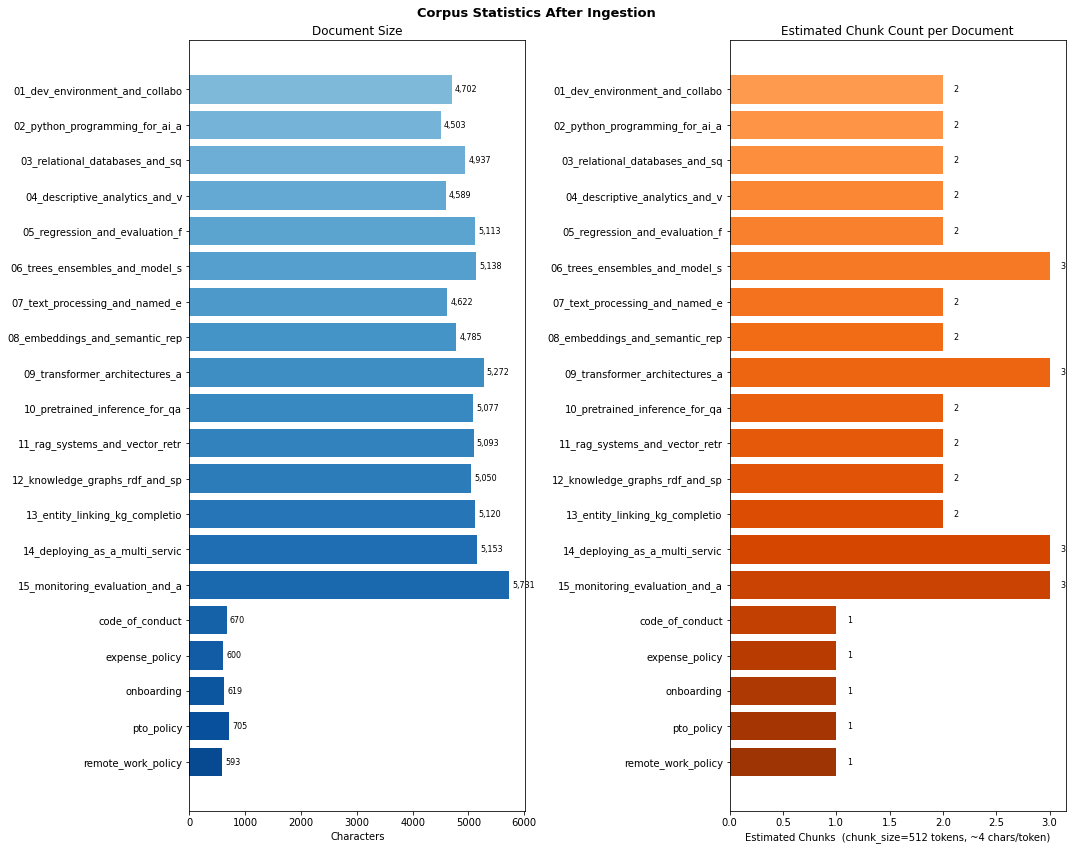

Total documents: 20  |  Total estimated chunks: 39


In [7]:
# ─────────────────────────────────────────────────────────────
#  VISUALIZATION — Corpus Statistics
#  After ingestion, show document sizes and estimated chunk
#  counts so you can spot imbalances before querying.
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

doc_names, doc_chars = [], []
for f in sorted(DATA_DIR.glob("*.md")):
    doc_names.append(f.stem[:30])          # truncate long names for readability
    doc_chars.append(len(f.read_text()))

chars_per_token  = 4                        # rough estimate: 1 token ≈ 4 characters
estimated_chunks = [max(1, round(c / (CHUNK_SIZE * chars_per_token))) for c in doc_chars]

fig, axes = plt.subplots(1, 2, figsize=(15, 0.5 * len(doc_names) + 2))
fig.suptitle("Corpus Statistics After Ingestion", fontsize=13, fontweight="bold")

# Left: document character counts
ax1 = axes[0]
blue_shades = plt.cm.Blues(np.linspace(0.45, 0.9, len(doc_names)))
bars1 = ax1.barh(doc_names, doc_chars, color=blue_shades)
ax1.set_xlabel("Characters")
ax1.set_title("Document Size")
ax1.invert_yaxis()
for bar, val in zip(bars1, doc_chars):
    ax1.text(val + max(doc_chars) * 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", fontsize=8)

# Right: estimated chunk counts
ax2 = axes[1]
orange_shades = plt.cm.Oranges(np.linspace(0.45, 0.9, len(doc_names)))
bars2 = ax2.barh(doc_names, estimated_chunks, color=orange_shades)
ax2.set_xlabel(f"Estimated Chunks  (chunk_size={CHUNK_SIZE} tokens, ~4 chars/token)")
ax2.set_title("Estimated Chunk Count per Document")
ax2.invert_yaxis()
for bar, val in zip(bars2, estimated_chunks):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=8)

plt.tight_layout()
plt.show()
print(f"Total documents: {len(doc_names)}  |  Total estimated chunks: {sum(estimated_chunks)}")

In [8]:
# ─────────────────────────────────────────────────────────────
#  STAGE 1 — RETRIEVER   (mirrors src/retriever.py)
#
#  This function is the SEAM between the data layer and the rest.
#  LangChain and LangGraph cells call retrieve() directly —
#  they never import anything from LlamaIndex.
#  This clean interface makes each layer independently swappable.
# ─────────────────────────────────────────────────────────────

def retrieve(query: str, top_k: int = TOP_K) -> List[str]:
    """Return the top-k most relevant chunk texts for `query`."""
    idx = load_index()                      # reload the persisted index (fast — just opens Chroma)
    retriever = idx.as_retriever(           # create a retriever object from the index
        similarity_top_k=top_k             # how many chunks to return (ranked by cosine similarity)
    )
    nodes = retriever.retrieve(query)       # embed the query and find the nearest chunk vectors
    return [n.node.get_content() for n in nodes]  # extract plain text from each NodeWithScore object


print("✅  retrieve() function defined.")

✅  retrieve() function defined.


In [9]:
# ─────────────────────────────────────────────────────────────
#  STAGE 1 VERIFICATION — Eyeball the chunks
#
#  Read these chunks carefully before adding any LLM.
#  Are they relevant to the question? Is the text complete?
# ─────────────────────────────────────────────────────────────

test_query = "How many PTO days do new employees get?"  # the question we want to answer in Stage 3
chunks = retrieve(test_query)               # call the retriever we just defined above

print(f"Query: {test_query!r}")
print(f"Retrieved {len(chunks)} chunk(s):\n")
for i, chunk in enumerate(chunks, 1):      # enumerate starting at 1 for human-readable numbering
    print(f"─── Chunk {i} " + "─" * 48)
    print(textwrap.fill(chunk[:500], width=72))  # wrap long lines at 72 chars for readable output
    print()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2759.23it/s]


LLM is explicitly disabled. Using MockLLM.
Query: 'How many PTO days do new employees get?'
Retrieved 4 chunk(s):

─── Chunk 1 ────────────────────────────────────────────────
# PTO Policy  ## Paid Time Off for Full-Time Employees  All full-time
employees at Meridian Software receive **20 PTO days per calendar year**
starting from their first day of employment. New employees in their
first 90 days receive the same entitlement and may take PTO immediately
with manager approval.  PTO days do not roll over into the following
year. Any unused days are forfeited on December 31. Employees who resign
or are terminated are paid out for unused PTO days accrued in the
current c

─── Chunk 2 ────────────────────────────────────────────────
# Remote Work Policy  ## Hybrid-First Work Environment  Meridian
Software operates on a **hybrid-first** model. Employees may work
remotely up to **3 days per week**. The remaining 2 days should be
worked from the office or an approved co-working space.  Fully 

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2712.09it/s]


LLM is explicitly disabled. Using MockLLM.


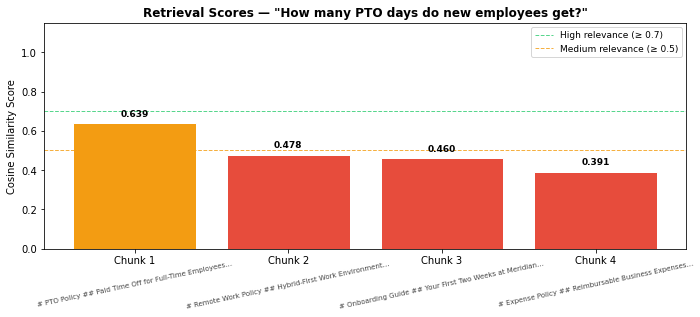

In [10]:
# ─────────────────────────────────────────────────────────────
#  VISUALIZATION — Retrieval Similarity Scores
#  Cosine similarity for each returned chunk reveals how
#  confidently the vector index matched the query.
#  Green ≥ 0.7 | Yellow ≥ 0.5 | Red < 0.5
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import textwrap as tw


def retrieve_with_scores(query: str, top_k: int = TOP_K):
    """Return list of (chunk_text, cosine_score) for the query."""
    idx = load_index()
    nodes = idx.as_retriever(similarity_top_k=top_k).retrieve(query)
    return [(n.node.get_content(), n.score) for n in nodes]


vis_query    = "How many PTO days do new employees get?"
scored       = retrieve_with_scores(vis_query)
labels       = [f"Chunk {i+1}" for i in range(len(scored))]
scores       = [s for _, s in scored]
previews     = [tw.shorten(text[:100], width=55, placeholder="…") for text, _ in scored]
bar_colors   = ["#2ecc71" if s >= 0.7 else "#f39c12" if s >= 0.5 else "#e74c3c"
                for s in scores]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, scores, color=bar_colors, edgecolor="white", linewidth=1)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Cosine Similarity Score")
ax.set_title(f'Retrieval Scores — "{vis_query}"', fontsize=12, fontweight="bold")

ax.axhline(0.7, color="#2ecc71", linestyle="--", linewidth=1, alpha=0.8,
           label="High relevance (≥ 0.7)")
ax.axhline(0.5, color="#f39c12", linestyle="--", linewidth=1, alpha=0.8,
           label="Medium relevance (≥ 0.5)")

for bar, score, preview in zip(bars, scores, previews):
    cx = bar.get_x() + bar.get_width() / 2
    ax.text(cx, score + 0.025, f"{score:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(cx, -0.06, preview, ha="center", va="top",
            fontsize=7, color="#444", rotation=12)

ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

### ✅ Stage 1 Checkpoint

If the chunks above contain text about PTO days, retrieval is working.

**Before moving on:**
- Are the chunks clearly about PTO? (they should be)
- Try `retrieve("what is the expense limit per person")` — do you get the expense policy?
- If chunks look truncated, try increasing `CHUNK_SIZE` in the config cell.



---

## Stage 2 — LangChain: The Generation Layer

**What LangChain does here:**
It wires together prompts, LLM calls, and structured output into composable chains.
The key advantage over raw API calls: the answer comes back as a **typed Python object**,
not a string you have to scrape.

| Object | Job |
|--------|-----|
| `CitedAnswer` | Pydantic model — shape of a valid answer (`answer`, `sources`, `confidence`) |
| `generation_chain` | `ChatPromptTemplate \| ChatOllama.with_structured_output(CitedAnswer)` |
| `RelevanceGrade` | Pydantic model — grader verdict (`relevant`/`not_relevant` + reason) |
| `grader_chain` | Same pattern, used as the LLM-as-judge in Stage 3 |

**Why structured output matters:**
Once the answer is a Pydantic object, Stage 3 nodes can read `grade.verdict` or
`answer.confidence` without any string parsing — LLM output is just data.

> **Note:** `llama3.2:3b` follows structured schemas reliably for simple shapes like these.
> If you see parse errors, switch to `llama3.1:8b` for higher compliance.

In [11]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 — OUTPUT MODELS
#
#  Define the SHAPE of what we want back from the LLM before
#  writing a single prompt.  Pydantic enforces the schema so
#  we always get a Python object — never raw text to parse.
# ─────────────────────────────────────────────────────────────

from pydantic import BaseModel, Field       # Pydantic: define data schemas with validation


class CitedAnswer(BaseModel):               # the structured shape of every generated answer
    """Structured answer returned by the generation chain."""
    answer: str = Field(                    # the text answer — must come from the provided context only
        description="A clear, direct answer based only on the provided context."
    )
    sources: List[str] = Field(             # list of document names that back up the answer
        description="Document names or section titles that support the answer."
    )
    confidence: Literal["high", "medium", "low"] = Field(  # forces exactly one of three values
        description=(
            "high: context directly and completely answers the question. "
            "medium: context partially answers it. "
            "low: context is only tangentially related."
        )
    )


class RelevanceGrade(BaseModel):            # the grader's verdict for Stage 3's conditional routing
    """Grader verdict on whether retrieved context is useful for a question."""
    verdict: Literal["relevant", "not_relevant"] = Field(  # exactly two allowed verdicts
        description="'relevant' if the context helps answer the question, 'not_relevant' otherwise."
    )
    reason: str = Field(                    # one-sentence explanation shown in the node-path trace
        description="One sentence explaining the verdict."
    )


print("✅  Pydantic models defined: CitedAnswer, RelevanceGrade")

✅  Pydantic models defined: CitedAnswer, RelevanceGrade


In [12]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 — GENERATION CHAIN   (mirrors src/generation.py)
#
#  Ollama <0.5.0 does not support JSON-schema in the `format`
#  field, so we use format="json" (forces valid JSON output)
#  and add schema instructions to the system prompt instead.
#  JsonOutputParser parses the JSON string → dict, then we
#  validate it into a CitedAnswer Pydantic object.
#
#  Chain pattern:
#    ChatPromptTemplate | ChatOllama(format="json") | JsonOutputParser() | CitedAnswer
# ─────────────────────────────────────────────────────────────

from langchain_ollama import ChatOllama                      # LangChain adapter: wraps a local Ollama model
from langchain_core.prompts import ChatPromptTemplate        # builds structured (system, human) prompt templates
from langchain_core.output_parsers import JsonOutputParser   # parses the LLM's JSON string into a Python dict


GENERATION_PROMPT = ChatPromptTemplate.from_messages([
    (
        "system",                            # system message: role + JSON schema instructions
        "You are a helpful assistant for Meridian Software employees. "
        "Answer questions using ONLY the provided context. "
        "If the context does not contain enough information, say so — "
        "do not invent or extrapolate policies.\n\n"
        "Respond with a JSON object containing exactly these fields:\n"
        '  "answer":     string — a clear, direct answer based only on the context\n'
        '  "sources":    list of strings — document names or section titles that support the answer\n'
        '  "confidence": one of "high", "medium", or "low"\n'
        "                high=context directly answers it, medium=partial, low=tangential",
    ),
    (
        "human",                             # human message: inject retrieved context and the question
        "Context from the employee handbook:\n\n{context}\n\n"
        "Question: {question}\n\n"
        "Answer the question using only the context above.",
    ),
])

_generation_llm = ChatOllama(model=LLM_MODEL, format="json")  # format="json" forces valid JSON output
generation_chain = (
    GENERATION_PROMPT
    | _generation_llm
    | JsonOutputParser()                     # parses JSON string → Python dict
    | (lambda d: CitedAnswer(**d))           # validates dict → CitedAnswer Pydantic object
)

print("✅  generation_chain ready:  prompt → ChatOllama(json) → CitedAnswer")


✅  generation_chain ready:  prompt → ChatOllama(json) → CitedAnswer


In [13]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 — GRADER CHAIN   (mirrors src/grader.py)
#
#  The grader is a second LLM call that acts as a judge.
#  It answers one question: "Is this retrieved context relevant?"
#
#  Ollama <0.5.0 does not support JSON-schema in the `format`
#  field, so we use format="json" (forces valid JSON output)
#  and add schema instructions to the system prompt instead.
#  JsonOutputParser parses the JSON string → dict, then we
#  validate it into a RelevanceGrade Pydantic object.
#
#  In Stage 3, the verdict drives the graph's conditional routing.
# ─────────────────────────────────────────────────────────────

GRADER_PROMPT = ChatPromptTemplate.from_messages([  # separate prompt template for the grader
    (
        "system",                           # strict grader persona — avoids leniency bias
        "You are a retrieval quality grader. "
        "Decide whether a retrieved passage can meaningfully help answer a user's question. "
        "Be strict: if the passage is off-topic or only tangentially related, "
        "mark it as not_relevant.\n\n"
        "Respond with a JSON object containing exactly these fields:\n"
        '  "verdict": either "relevant" or "not_relevant"\n'
        '  "reason":  one sentence explaining your verdict',
    ),
    (
        "human",                            # inject the retrieved text and the question
        "Retrieved passage:\n\n{context}\n\n"  # {context} = the chunks joined into one string
        "User question: {question}\n\n"   # {question} = the original user question
        "Is this passage relevant to the question?",
    ),
])

_grader_llm = ChatOllama(model=GRADER_MODEL, format="json")  # format="json" forces valid JSON output
grader_chain = (
    GRADER_PROMPT
    | _grader_llm
    | JsonOutputParser()                    # parses JSON string → Python dict
    | (lambda d: RelevanceGrade(**d))       # validates dict → RelevanceGrade Pydantic object
)

print("✅  grader_chain ready:  prompt → ChatOllama(json) → RelevanceGrade")

✅  grader_chain ready:  prompt → ChatOllama(json) → RelevanceGrade


In [14]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 VERIFICATION — Linear RAG (no graph yet)
#
#  Flow: retrieve → generate   (no grading, no retry)
#  This confirms Stage 1 retrieval + Stage 2 generation connect.
# ─────────────────────────────────────────────────────────────

def linear_rag(question: str) -> CitedAnswer:  # a straight-line RAG call with no self-correction
    """Retrieve chunks, then generate a structured answer. No looping."""
    chunks = retrieve(question)             # Stage 1: get the top-k relevant chunks
    context_text = "\n\n---\n\n".join(chunks)  # join chunks with a separator so the LLM sees clear boundaries
    return generation_chain.invoke(         # Stage 2: run the LangChain chain
        {"context": context_text,           # fill the {context} slot in the prompt
         "question": question}              # fill the {question} slot in the prompt
    )                                       # returns a CitedAnswer Pydantic object


q   = "How many PTO days do new employees get?"  # a question that IS in the handbook
ans = linear_rag(q)                         # run the linear RAG call

print(f"Question:   {q}")
print(f"Answer:     {ans.answer}")          # the text answer extracted from CitedAnswer
print(f"Confidence: {ans.confidence}")      # "high", "medium", or "low"
print(f"Sources:    {ans.sources}")         # list of source names cited by the model
print()
print("─" * 60)
print("NOTE: this linear version has no self-correction.")
print("Try asking it something not in the docs — it will hallucinate.")
print("Stage 3 fixes that.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2802.14it/s]


LLM is explicitly disabled. Using MockLLM.
Question:   How many PTO days do new employees get?
Answer:     All full-time employees at Meridian Software, including new employees during their first 90 days of employment, receive **20 Paid Time Off (PTO) days per calendar year**.
Confidence: high
Sources:    ['# PTO Policy', '### Requesting Time Off']

────────────────────────────────────────────────────────────
NOTE: this linear version has no self-correction.
Try asking it something not in the docs — it will hallucinate.
Stage 3 fixes that.


## Stage 2 — LangGraph: The Control Layer

**What LangGraph does here:**
It defines a directed graph of nodes (Python functions) connected by edges.
Conditional edges let the graph branch based on state values. Unlike a chain, a graph can **loop**.

**The corrective-RAG graph:**

```
        question
            │
            ▼
        [retrieve]  ◀───────────────────────────┐
            │                                   │
            ▼                                   │
         [grade]                                │
            │                                   │
    ┌───────┴────────┐                          │
  relevant?      not relevant?                  │
    │                 │                         │
    ▼           retries < MAX?                  │
[generate]           │                         │
    │          ┌─────┴──────┐                  │
    ▼          YES          NO                 │
   END      [rewrite] ──────┘            [fallback]
                                               │
                                               ▼
                                              END
```

**Nodes:** `retrieve` · `grade` · `rewrite` · `generate` · `fallback`



In [ ]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 — GRAPH STATE
#
#  The state is a typed dict — a shared "notebook" every node
#  reads from and writes back to.
#
#  Each node returns a PARTIAL dict (only the keys it changed).
#  LangGraph merges those partial updates into the running state.
#
#  node_path uses operator.add as a reducer: instead of
#  overwriting the list, LangGraph APPENDS each node's name.
# ─────────────────────────────────────────────────────────────

class GraphState(TypedDict):                # typed dictionary — each field has a declared type
    question:     str                       # the original user question — set once, never changed
    search_query: str                       # the current search query — may be rewritten by node_rewrite
    context:      List[str]                 # text chunks returned by the most recent retrieve() call
    grade:        str                       # grader verdict: "relevant" or "not_relevant"
    grade_reason: str                       # the grader's one-sentence explanation of its verdict
    answer:       Optional[dict]            # final answer dict (set by node_generate or node_fallback)
    retry_count:  int                       # incremented by node_rewrite; stops the loop at MAX_RETRIES
    node_path:    Annotated[List[str], add] # execution trace — add reducer APPENDS instead of overwriting


print("✅  GraphState defined")

✅  GraphState defined


In [ ]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 — GRAPH NODES
#
#  Each node is a function:  GraphState → dict
#  It reads what it needs from state, does ONE job,
#  and returns only the keys it changed.
# ─────────────────────────────────────────────────────────────

from langchain_ollama import ChatOllama     # repeated import for clarity — already loaded in c14


# ── 1. retrieve ──────────────────────────────────────────────────────────────
def node_retrieve(state: GraphState) -> dict:  # node signature: receives full state, returns partial update
    """Fetch the top-k chunks for the current search query."""
    query = state.get("search_query") or state["question"]  # use rewritten query if available, else original
    print(f"  [retrieve] query={query!r}")
    chunks = retrieve(query)               # call the Stage 1 retriever
    return {
        "context":   chunks,               # store the retrieved chunks in state
        "node_path": ["retrieve"],         # append "retrieve" to the execution trace
    }


# ── 2. grade ─────────────────────────────────────────────────────────────────
def node_grade(state: GraphState) -> dict:
    """Ask the grader LLM whether the retrieved context is relevant."""
    context_text = "\n\n---\n\n".join(state["context"])  # join all chunks with a visible separator
    result: RelevanceGrade = grader_chain.invoke({  # type annotation helps editors and readers
        "context":  context_text,          # the retrieved text to evaluate
        "question": state["question"],     # the original question (not the rewritten query)
    })
    print(f"  [grade]    verdict={result.verdict!r}  |  {result.reason}")
    return {
        "grade":        result.verdict,    # "relevant" or "not_relevant" — drives the conditional edge
        "grade_reason": result.reason,     # one-sentence explanation for transparency
        "node_path":    ["grade"],         # append "grade" to the execution trace
    }


# ── 3. rewrite ───────────────────────────────────────────────────────────────
_rewrite_prompt = ChatPromptTemplate.from_messages([  # dedicated prompt for query rewriting
    (
        "human",
        "The search query below did not return useful results from an employee handbook.\n"
        "Rewrite it to be more specific and more likely to find the relevant policy.\n\n"
        "Original query: {query}\n\n"    # {query} is filled with the current (failing) query
        "Rewritten query (return only the rewritten query, no explanation):"
    )
])
_rewrite_chain = _rewrite_prompt | ChatOllama(model=LLM_MODEL)  # simple chain: prompt → raw text response

def node_rewrite(state: GraphState) -> dict:
    """Rephrase the search query to retrieve better context on the next loop."""
    old_query = state.get("search_query") or state["question"]  # current query to rephrase
    response  = _rewrite_chain.invoke({"query": old_query})  # ask the LLM for a better query
    new_query = response.content.strip()   # .content extracts the text; .strip() removes whitespace
    print(f"  [rewrite]  '{old_query}' → '{new_query}'")
    return {
        "search_query": new_query,         # the improved query that retrieve will use next loop
        "retry_count":  state["retry_count"] + 1,  # increment the counter to enforce MAX_RETRIES
        "node_path":    ["rewrite"],       # append "rewrite" to the execution trace
    }


# ── 4. generate ──────────────────────────────────────────────────────────────
def node_generate(state: GraphState) -> dict:
    """Call the generation chain to produce the final structured answer."""
    context_text = "\n\n---\n\n".join(state["context"])  # join chunks for the generation prompt
    result: CitedAnswer = generation_chain.invoke({
        "context":  context_text,          # the relevant retrieved text
        "question": state["question"],     # the original user question (not the rewritten query)
    })
    print(f"  [generate] confidence={result.confidence!r}")
    return {
        "answer":    result.model_dump(),  # convert CitedAnswer Pydantic object → plain dict for state storage
        "node_path": ["generate"],         # append "generate" to the execution trace
    }


# ── 5. fallback ──────────────────────────────────────────────────────────────
def node_fallback(state: GraphState) -> dict:
    """Return an honest 'I don't know' when MAX_RETRIES is exhausted."""
    # This node is the most important in the graph: it prevents hallucination
    # when no relevant context can be found after all retry attempts.
    print(f"  [fallback] {MAX_RETRIES} retries exhausted — returning honest answer")
    return {
        "answer": {
            "answer": (
                "I could not find relevant information in the Meridian employee handbook "  # honest admission
                "to answer this question. Please check with HR or your manager directly."  # helpful redirect
            ),
            "sources":    [],              # no sources because we found nothing relevant
            "confidence": "low",           # signals to the caller that this is a fallback answer
        },
        "node_path": ["fallback"],         # append "fallback" to the execution trace
    }


print("✅  All 5 node functions defined: retrieve, grade, rewrite, generate, fallback")

✅  All 5 node functions defined: retrieve, grade, rewrite, generate, fallback


In [ ]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 — BUILD & COMPILE THE GRAPH   (mirrors src/graph.py)
#
#  StateGraph is the builder object.  You declare nodes and
#  edges, then call .compile() to produce a runnable Pregel graph.
# ─────────────────────────────────────────────────────────────

from langgraph.graph import StateGraph, START, END  # StateGraph=builder, START/END=sentinel node names


def route_after_grade(state: GraphState) -> str:  # routing function: inspects state, returns next node name
    """Branch after grading: generate | rewrite | fallback."""
    if state["grade"] == "relevant":        # context is good enough — go straight to generation
        return "generate"
    elif state["retry_count"] >= MAX_RETRIES:  # context is still bad after MAX_RETRIES rewrites
        return "fallback"                   # give up gracefully rather than looping forever
    else:
        return "rewrite"                    # context bad but retries remain — rephrase and try again


builder = StateGraph(GraphState)            # create the graph builder, typed to our state schema

builder.add_node("retrieve", node_retrieve)  # register node: name used in edges + trace output
builder.add_node("grade",    node_grade)    # register node
builder.add_node("rewrite",  node_rewrite)  # register node
builder.add_node("generate", node_generate) # register node
builder.add_node("fallback", node_fallback) # register node

builder.add_edge(START,      "retrieve")    # START is a sentinel: the graph enters at "retrieve"
builder.add_edge("retrieve", "grade")       # fixed edge: after every retrieve, always grade
builder.add_edge("rewrite",  "retrieve")    # fixed edge: the retry loop — rewrite feeds back into retrieve
builder.add_edge("generate", END)           # fixed edge: generation ends the graph
builder.add_edge("fallback", END)           # fixed edge: fallback also ends the graph

builder.add_conditional_edges(              # conditional: the routing function decides which edge to take
    "grade",                                # this node's output triggers the routing decision
    route_after_grade,                      # the function that inspects state and returns a node name
    {                                       # map: returned string → actual node object
        "generate": "generate",
        "rewrite":  "rewrite",
        "fallback": "fallback",
    },
)

graph = builder.compile()                   # compile the builder into a runnable LangGraph Pregel object

print("✅  LangGraph graph compiled successfully")
print(f"    Nodes: retrieve → grade → (generate | rewrite → ... | fallback)")
print(f"    Config: MAX_RETRIES={MAX_RETRIES}, TOP_K={TOP_K}")

✅  LangGraph graph compiled successfully
    Nodes: retrieve → grade → (generate | rewrite → ... | fallback)
    Config: MAX_RETRIES=2, TOP_K=4


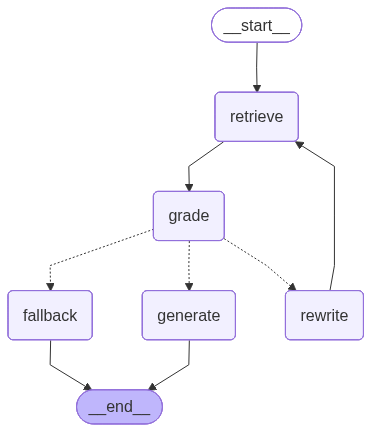

✅  Graph rendered via LangGraph Mermaid renderer.


In [18]:
# ─────────────────────────────────────────────────────────────
#  VISUALIZATION — LangGraph Structure
#  Renders the compiled graph as a flow diagram.
#  Tries the built-in Mermaid PNG renderer first;
#  falls back to a matplotlib/networkx diagram if unavailable.
# ─────────────────────────────────────────────────────────────

from IPython.display import Image, display

try:
    png_bytes = graph.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
    print("✅  Graph rendered via LangGraph Mermaid renderer.")

except Exception as mermaid_err:
    print(f"Mermaid renderer unavailable ({mermaid_err}) — using matplotlib fallback.")

    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import networkx as nx

    G = nx.DiGraph()
    node_list = ["START", "retrieve", "grade", "rewrite", "generate", "fallback", "END"]
    G.add_nodes_from(node_list)
    G.add_edges_from([
        ("START",    "retrieve"),
        ("retrieve", "grade"),
        ("grade",    "generate"),    # conditional: relevant
        ("grade",    "rewrite"),     # conditional: not_relevant + retries remain
        ("grade",    "fallback"),    # conditional: retries exhausted
        ("rewrite",  "retrieve"),    # loop back
        ("generate", "END"),
        ("fallback", "END"),
    ])

    pos = {
        "START":    (2.0, 6.0),
        "retrieve": (2.0, 4.8),
        "grade":    (2.0, 3.6),
        "generate": (0.3, 2.0),
        "rewrite":  (2.0, 2.0),
        "fallback": (3.7, 2.0),
        "END":      (2.0, 0.8),
    }
    node_color_map = {
        "START":    "#95a5a6",  "END":      "#95a5a6",
        "retrieve": "#3498db",  "grade":    "#9b59b6",
        "generate": "#2ecc71",  "rewrite":  "#f39c12",
        "fallback": "#e74c3c",
    }
    ordered_colors = [node_color_map[n] for n in node_list]

    edge_labels = {
        ("grade", "generate"): "relevant",
        ("grade", "rewrite"):  "not relevant\n+ retries left",
        ("grade", "fallback"): "not relevant\n+ retries exhausted",
    }

    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=ordered_colors,
                           node_size=2200, alpha=0.95)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                            font_color="white", font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=22,
                           edge_color="#555", width=1.8,
                           connectionstyle="arc3,rad=0.08", min_source_margin=30,
                           min_target_margin=30)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=7.5, label_pos=0.45)

    ax.set_title("LangGraph Corrective-RAG Structure", fontsize=13, fontweight="bold")
    ax.axis("off")

    legend_handles = [
        mpatches.Patch(color="#3498db", label="retrieve  ← LlamaIndex"),
        mpatches.Patch(color="#9b59b6", label="grade     ← LangChain"),
        mpatches.Patch(color="#2ecc71", label="generate  ← LangChain"),
        mpatches.Patch(color="#f39c12", label="rewrite   ← LangChain"),
        mpatches.Patch(color="#e74c3c", label="fallback"),
    ]
    ax.legend(handles=legend_handles, loc="lower left", fontsize=8.5, framealpha=0.9)
    plt.tight_layout()
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
#  STAGE 2 — RUN THE ASSISTANT   (mirrors src/app.py)
#
#  run_assistant() is the full app in one function:
#    1. Build the initial state dict
#    2. Invoke the compiled graph
#    3. Print the node path  ← the teaching payoff
#    4. Pretty-print the structured answer
# ─────────────────────────────────────────────────────────────

def run_assistant(question: str) -> dict:   # accepts any question; returns the final graph state
    """Run the corrective-RAG graph and pretty-print results."""
    print(f"\n{'═' * 60}")
    print(f"QUESTION: {question}")
    print('═' * 60)

    initial_state: GraphState = {           # every field must be present — LangGraph validates the schema
        "question":     question,           # the user's question — stored here and never overwritten
        "search_query": question,           # starts as the raw question; node_rewrite may update this
        "context":      [],                 # empty until the first node_retrieve runs
        "grade":        "",                 # empty until the first node_grade runs
        "grade_reason": "",                 # empty until the first node_grade runs
        "answer":       None,               # None until node_generate or node_fallback runs
        "retry_count":  0,                  # starts at 0; incremented by node_rewrite each loop
        "node_path":    [],                 # starts empty; each node appends its own name via the add reducer
    }

    final_state = graph.invoke(initial_state)  # run the graph to completion; blocks until END is reached

    path = " → ".join(final_state["node_path"])  # join the execution trace list into a readable string
    print(f"\nNODE PATH:  {path}")          # THE teaching payoff: shows every decision the graph made

    ans = final_state["answer"]             # retrieve the final answer dict from the completed state
    print(f"\nANSWER:     {ans['answer']}")  # the text answer
    print(f"CONFIDENCE: {ans['confidence']}")  # "high", "medium", or "low"
    if ans["sources"]:                      # only print sources if the model cited any
        print(f"SOURCES:    {', '.join(ans['sources'])}")

    return final_state                      # return full state so the caller can inspect any field


# ── Easy question — expected: retrieve → grade → generate ────────────────────
result_easy = run_assistant("How many PTO days do new employees get?")


════════════════════════════════════════════════════════════
QUESTION: How many PTO days do new employees get?
════════════════════════════════════════════════════════════
  [retrieve] query='How many PTO days do new employees get?'


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2831.52it/s]


LLM is explicitly disabled. Using MockLLM.
  [grade]    verdict='relevant'  |  The retrieved passage provides specific information about how many paid time off (PTO) days full-time and new employees at Meridian Software receive.
  [generate] confidence='high'

NODE PATH:  retrieve → grade → generate

ANSWER:     New employees receive 20 PTO days per calendar year, including their first day of employment.
CONFIDENCE: high
SOURCES:    # PTO Policy, 'Paid Time Off for Full-Time Employees' section


In [20]:
# ── Unanswerable question — expected: retrieve → grade → rewrite → retrieve → grade → fallback
# Cryptocurrency payments are not mentioned anywhere in the handbook.
# The grader marks the context as not_relevant → triggers node_rewrite.
# After MAX_RETRIES exhausted with no relevant context → node_fallback fires.

result_hard = run_assistant("What is the company's policy on cryptocurrency payments?")


════════════════════════════════════════════════════════════
QUESTION: What is the company's policy on cryptocurrency payments?
════════════════════════════════════════════════════════════
  [retrieve] query="What is the company's policy on cryptocurrency payments?"


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2691.41it/s]


LLM is explicitly disabled. Using MockLLM.
  [grade]    verdict='not_relevant'  |  The retrieved passage discusses Meridian Software's policies regarding business expenses, remote work, PTO, and their representative workflow for deploying services but does not mention any policy on cryptocurrency payments.
  [rewrite]  'What is the company's policy on cryptocurrency payments?' → '"What are the guidelines for using digital currencies as a form of payment within our organization?"'
  [retrieve] query='"What are the guidelines for using digital currencies as a form of payment within our organization?"'


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3413.77it/s]


LLM is explicitly disabled. Using MockLLM.
  [grade]    verdict='not_relevant'  |  The retrieved passage discusses Meridian Software's expense and remote work policies, which are unrelated to any company policy regarding cryptocurrency payments.
  [rewrite]  '"What are the guidelines for using digital currencies as a form of payment within our organization?"' → 'Revised Search Query: "Digital currency acceptance policies in [Your Organization's Name] handbook"'
  [retrieve] query='Revised Search Query: "Digital currency acceptance policies in [Your Organization\'s Name] handbook"'


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2418.11it/s]


LLM is explicitly disabled. Using MockLLM.
  [grade]    verdict='not_relevant'  |  The retrieved passage discusses Meridian Software's expense and remote work policies, not their stance on accepting cryptocurrency for payments.
  [fallback] 2 retries exhausted — returning honest answer

NODE PATH:  retrieve → grade → rewrite → retrieve → grade → rewrite → retrieve → grade → fallback

ANSWER:     I could not find relevant information in the Meridian employee handbook to answer this question. Please check with HR or your manager directly.
CONFIDENCE: low


/tmp/ipykernel_1015952/3217129378.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.07, 1, 1])
/tmp/ipykernel_1015952/3217129378.py:62: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.07, 1, 1])
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


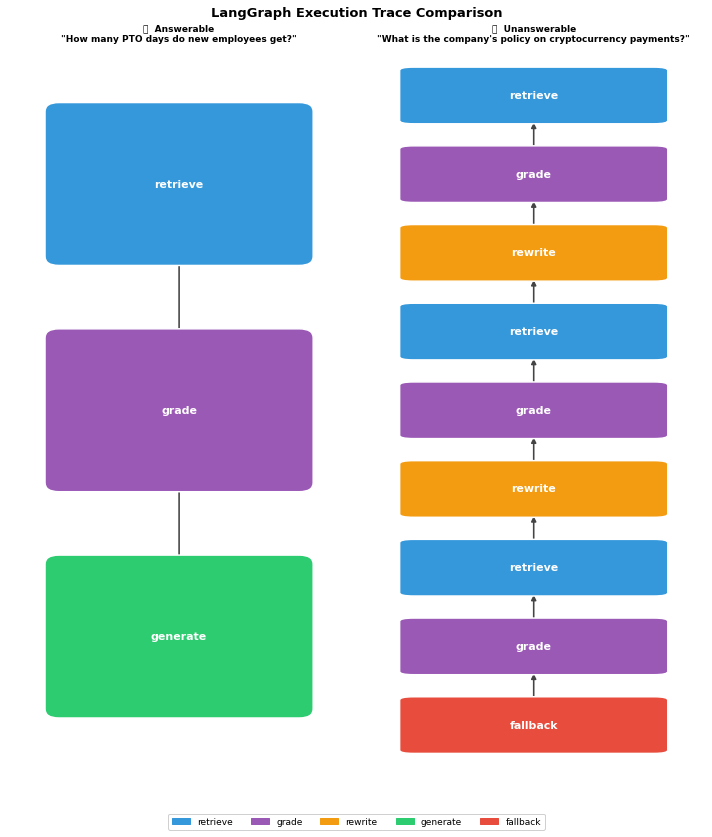


Easy path  (3 nodes): retrieve → grade → generate
Hard path  (9 nodes): retrieve → grade → rewrite → retrieve → grade → rewrite → retrieve → grade → fallback


In [21]:
# ─────────────────────────────────────────────────────────────
#  VISUALIZATION — Execution Trace Comparison
#  Side-by-side node paths from the two runs above.
#  The color-coded boxes make every routing decision visible.
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

NODE_COLORS = {
    "retrieve": "#3498db",
    "grade":    "#9b59b6",
    "rewrite":  "#f39c12",
    "generate": "#2ecc71",
    "fallback": "#e74c3c",
}


def draw_trace(ax, path, title, question):
    """Draw a vertical stack of labeled boxes with connecting arrows."""
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.6, len(path) - 0.4)
    ax.axis("off")
    ax.set_title(f"{title}\n\"{question}\"", fontsize=9, fontweight="bold", pad=8,
                 wrap=True)

    for i, node in enumerate(path):
        y = len(path) - 1 - i
        color = NODE_COLORS.get(node, "#95a5a6")
        box = mpatches.FancyBboxPatch(
            (0.15, y - 0.32), 0.70, 0.64,
            boxstyle="round,pad=0.04",
            facecolor=color, edgecolor="white", linewidth=1.5, zorder=2,
        )
        ax.add_patch(box)
        ax.text(0.50, y, node, ha="center", va="center",
                fontsize=11, fontweight="bold", color="white", zorder=3)
        if i < len(path) - 1:
            ax.annotate(
                "", xy=(0.50, y - 0.32), xytext=(0.50, y - 0.68),
                arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.6),
                zorder=1,
            )


easy_path = result_easy["node_path"]
hard_path = result_hard["node_path"]
max_len   = max(len(easy_path), len(hard_path))

fig, axes = plt.subplots(1, 2, figsize=(10, max_len * 1.15 + 1.5))
fig.suptitle("LangGraph Execution Trace Comparison", fontsize=13, fontweight="bold")

draw_trace(axes[0], easy_path,
           "✅  Answerable", "How many PTO days do new employees get?")
draw_trace(axes[1], hard_path,
           "❌  Unanswerable", "What is the company's policy on cryptocurrency payments?")

legend_handles = [mpatches.Patch(color=c, label=n) for n, c in NODE_COLORS.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=5,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

print(f"\nEasy path  ({len(easy_path)} nodes): {' → '.join(easy_path)}")
print(f"Hard path  ({len(hard_path)} nodes): {' → '.join(hard_path)}")

### ✅ Stage 3 Checkpoint

Compare the two node paths:

| Question | Expected Path |
|----------|--------------|
| "How many PTO days?" | `retrieve → grade → generate` |
| "Cryptocurrency payments?" | `retrieve → grade → rewrite → retrieve → grade → fallback` |


---

## Recap: Which Library Owns Which Layer?

| Layer | Library | Responsibility |
|-------|---------|----------------|
| **Data** | LlamaIndex | Load, chunk, embed, index, retrieve |
| **Generation** | LangChain | Prompt template, LLM call, structured output |
| **Control** | LangGraph | State machine, branching, looping, fallback |

These libraries are not competitors — each one does one job well.

---

## Extensions to Try

1. **Web-search fallback** — replace `node_fallback` with a search node (Tavily, DuckDuckGo)
   so the assistant can answer questions outside the handbook.

2. **Conversation memory** — add a `messages` field to `GraphState` with an `add_messages`
   reducer so the assistant remembers previous turns.

3. **Evaluation** — build a small Q&A set and score the answers automatically.
   That is the difference between a demo and something you would trust in production.

---
## Final Cell — Gradio UI

**What this cell does:**
1. **Rebuilds the index** — wipes the old `storage/` and re-ingests every `.md` file currently in `data/`, so any documents you've added since the last run are automatically included.
2. **Wraps the LangGraph graph** — captures node-path and answer fields as return values instead of `print()` calls, so Gradio can display them in labelled output boxes.
3. **Launches an interactive UI** — a question box, an answer panel, and three info chips showing confidence, sources, and the graph path the corrective-RAG took.

**Dependency:** run all cells above first so `ingest()`, `graph`, `GraphState`, `DATA_DIR`, and `STORAGE_DIR` are defined.

In [22]:
# ─────────────────────────────────────────────────────────────
#  FINAL CELL — Gradio UI
#
#  Run this after all cells above have been executed.
#  It rebuilds the index from data/ (so any new .md files you
#  dropped in are automatically picked up), then opens an
#  interactive question-answering interface in the notebook.
# ─────────────────────────────────────────────────────────────

import shutil
import gradio as gr

# ── 1. Rebuild the vector index from the current data/ folder ─
#       This wipes stale vectors and re-embeds every .md file,
#       so newly added documents are always included.
print(f"🔄  Rebuilding index from {DATA_DIR}/ ...")
if STORAGE_DIR.exists():
    shutil.rmtree(STORAGE_DIR)          # remove old Chroma database
index = ingest()                         # load → chunk → embed → persist
doc_count = len(list(DATA_DIR.glob("*.md")))
print(f"✅  {doc_count} document(s) indexed and ready.\n")


# ── 2. Query wrapper ──────────────────────────────────────────
#       graph.invoke() writes to `print()` inside each node.
#       This wrapper captures the structured fields Gradio needs.
def query_rag(question: str):
    """Run the corrective-RAG graph; return displayable strings."""
    question = question.strip()
    if not question:
        return "Please enter a question.", "", "", ""

    final_state = graph.invoke({            # run the full LangGraph pipeline
        "question":     question,
        "search_query": question,           # may be rewritten by node_rewrite
        "context":      [],
        "grade":        "",
        "grade_reason": "",
        "answer":       None,
        "retry_count":  0,
        "node_path":    [],                 # accumulated by the add reducer
    })

    ans        = final_state["answer"]
    node_path  = " → ".join(final_state["node_path"])
    answer     = ans["answer"]
    confidence = ans["confidence"].upper()  # HIGH / MEDIUM / LOW
    sources    = ", ".join(ans["sources"]) if ans.get("sources") else "—"

    return answer, confidence, sources, node_path


# ── 3. Build the Gradio interface ─────────────────────────────
with gr.Blocks(title="Doc Assistant", theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        "## 📚 Doc Assistant\n"
        "Ask anything about the **employee handbook** or the **bootcamp curriculum**.\n\n"
        "The corrective-RAG graph retrieves, grades context quality, "
        "rewrites the query if needed, and honestly says *I don't know* "
        "when nothing relevant is found."
    )

    # ── Input row ─────────────────────────────────────────────
    with gr.Row():
        question_box = gr.Textbox(
            label="Your question",
            placeholder="e.g. What are the two phases of a RAG pipeline?",
            lines=2,
            scale=5,
        )
        submit_btn = gr.Button("Ask ↵", variant="primary", scale=1, min_width=80)

    # ── Answer panel ──────────────────────────────────────────
    answer_box = gr.Textbox(label="Answer", lines=6, interactive=False)

    # ── Metadata row ──────────────────────────────────────────
    with gr.Row():
        confidence_box = gr.Textbox(
            label="Confidence", interactive=False, scale=1
        )
        sources_box = gr.Textbox(
            label="Sources",    interactive=False, scale=2
        )
        path_box = gr.Textbox(
            label="Graph path (LangGraph trace)", interactive=False, scale=3
        )

    # ── Example questions covering both doc sets ──────────────
    gr.Examples(
        label="Example questions — click to load",
        examples=[
            ["How many PTO days do new employees get?"],
            ["What is the monthly home-office stipend for remote workers?"],
            ["How do I submit an expense reimbursement?"],
            ["How do I report a code of conduct violation?"],
            ["What is RAG and why does it reduce hallucination?"],
            ["What are the two phases of a RAG pipeline?"],
            ["What does a transformer's attention mechanism do?"],
            ["What is the difference between a vector index and a relational database?"],
            ["What is the company's policy on cryptocurrency payments?"],
        ],
        inputs=question_box,
    )

    # ── Wire both the button click and Enter key ──────────────
    for trigger in (submit_btn.click, question_box.submit):
        trigger(
            fn=query_rag,
            inputs=question_box,
            outputs=[answer_box, confidence_box, sources_box, path_box],
        )

demo.launch(share=False)                    # share=True generates a public URL via Gradio tunnel

🔄  Rebuilding index from data/ ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2708.09it/s]


LLM is explicitly disabled. Using MockLLM.
📂  Loading documents from data/ ...
    Loaded 20 document(s).
⚙️   Building index (downloads BGE model on first run, ~130 MB) ...


Generating embeddings: 100%|██████████| 50/50 [00:25<00:00,  1.98it/s]
/tmp/ipykernel_1015952/1435272441.py:54: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Doc Assistant", theme=gr.themes.Soft()) as demo:


✅  Index built and held in memory (re-run ingest() after kernel restart)
✅  20 document(s) indexed and ready.

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [ ]:
# ─────────────────────────────────────────────────────────────
#  SHUTDOWN / CLEANUP
#
#  Uncomment and run the sections you need when you are done.
#  Everything below is commented out so this cell is safe to
#  run accidentally — it will do nothing until you opt in.
# ─────────────────────────────────────────────────────────────

# ── Stop the Ollama server ───────────────────────────────────
# import subprocess
# result = subprocess.run(["pkill", "-f", "ollama"], capture_output=True)
# print("Ollama stopped." if result.returncode == 0 else "Ollama was not running.")

# # # ── Release the in-memory Chroma index ──────────────────────
# chroma_client = None          # drop the singleton so Python can GC the memory
# index = None                   # drop the VectorStoreIndex reference too
# print("Chroma in-memory index released.")

# # # ── Restart the kernel (clears all variables) ────────────────
# import IPython
# IPython.Application.instance().kernel.do_shutdown(restart=True)

# print("Shutdown cell loaded — uncomment the sections above to use them.")


: 